In [ ]:
# =============================================================================
# 05b_spatial_maps.ipynb — VERSIÓN REVISADA COMPLETA
# Banco Burdwood — Análisis espacial de estrés de pH
# =============================================================================
# Cambios respecto a la versión anterior:
#   1. % de área en estrés calculado solo dentro de BBI+BBII (no bbox)
#   2. Gráfico de evolución temporal corregido con máscara BBI+BBII
#   3. Mapas nuevos pre/post cambio de régimen (2005) con pH invernal
#   4. Solo dos períodos (sin transición), corte en enero 2006
#
# Corte pre/post régimen: enero 2006
#   Justificación: cubre ambos puntos de cambio (BBI: sep-2005, BBII: nov-2005)
#   y coincide con año calendario completo
# =============================================================================
 

#### Librerias y paths

In [2]:
# =============================================================================
# CELDA 1 — Librerías y paths
# =============================================================================
 
import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
from shapely.ops import unary_union
 
BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
SHAPES_DIR    = os.path.join(BASE_DIR, "data", "raw", "shapes")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
 
# Períodos — corte en enero 2006 (después de ambos puntos CUSUM)
PERIOD_PRE  = (1985, 2005)
PERIOD_POST = (2006, 2024)
WINTER_MONTHS = [7, 8, 9]  # julio–septiembre (invierno austral)
 
print("Setup listo ✅")

Setup listo ✅


#### Cargar datos y shapes

In [3]:
# =============================================================================
# CELDA 2 — Cargar datos y shapes
# =============================================================================
 
# bbox para análisis espacial píxel a píxel
ds       = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
ph       = ds["ph"]
 
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
 
print(f"Dataset: {dict(ph.sizes)}")
print(f"Período: {str(ph.time.values[0])[:10]} → {str(ph.time.values[-1])[:10]}")

Dataset: {'time': 480, 'latitude': 14, 'longitude': 37}
Período: 1985-01-01 → 2024-12-01


#### Máscara BBI+BBII (para cálculos de % área)

In [5]:
# =============================================================================
# CELDA 3 — Máscara BBI+BBII (para cálculos de % área)
# =============================================================================
# Usamos intersects() con box de 0.25° para incluir píxeles en el borde
 
union_bbi  = bbi_shape.geometry.union_all()
union_bbii = bbii_shape.geometry.union_all()
bb_total   = unary_union([union_bbi, union_bbii])
 
lats = ph.latitude.values
lons = ph.longitude.values
LON, LAT = np.meshgrid(lons, lats)
 
res    = 0.25
pixels = [box(lo-res/2, la-res/2, lo+res/2, la+res/2)
          for lo, la in zip(LON.ravel(), LAT.ravel())]
inside = np.array([bb_total.intersects(p) for p in pixels]).reshape(LAT.shape)

print(f"Píxeles dentro de BBI+BBII: {inside.sum()} de {inside.size}")

 
# pH enmascarado — solo píxeles dentro de BBI+BBII
ph_bb = ph.where(inside)
 

 

Píxeles dentro de BBI+BBII: 168 de 518


#### Percentil 5 local (por píxel, sobre toda la serie)

In [6]:
# =============================================================================
# CELDA 4 — Percentil 5 local (por píxel, sobre toda la serie)
# =============================================================================
# El umbral se calcula sobre TODA la grilla bbox para que sea consistente
# con el análisis espacial. Para el % de área en estrés se aplica la
# máscara del BB después.
 
print("Calculando percentil 5 local...")
ph_p05 = ph.quantile(0.05, dim="time")
print(f"  rango: {float(ph_p05.min()):.4f} – {float(ph_p05.max()):.4f}")

Calculando percentil 5 local...
  rango: 8.0332 – 8.0432


#### Serie temporal del % de área en estrés (dentro de BBI+BBII)

In [7]:
# =============================================================================
# CELDA 5 — Serie temporal del % de área en estrés (dentro de BBI+BBII)
# =============================================================================
 
# Máscara de estrés sobre píxeles del BB
stress_mask_bb = ph_bb < ph_p05
 
# % de área en estrés por mes
n_stress = stress_mask_bb.sum(dim=["latitude", "longitude"])
n_valid  = (~ph_bb.isnull()).sum(dim=["latitude", "longitude"])
pct_stress = 100 * n_stress / n_valid
 
df_stress_ts = pct_stress.to_dataframe(name="pct_stress").reset_index()
df_stress_ts["time"]  = pd.to_datetime(df_stress_ts["time"])
df_stress_ts["year"]  = df_stress_ts["time"].dt.year
df_stress_ts["month"] = df_stress_ts["time"].dt.month
 
print(f"Primer mes con estrés: "
      f"{df_stress_ts[df_stress_ts['pct_stress']>0]['time'].min().strftime('%Y-%m')}")
print(f"Máx % área en estrés : {df_stress_ts['pct_stress'].max():.1f}%")

Primer mes con estrés: 2017-08
Máx % área en estrés : 100.0%


#### Gráfico de evolución temporal del área en estrés

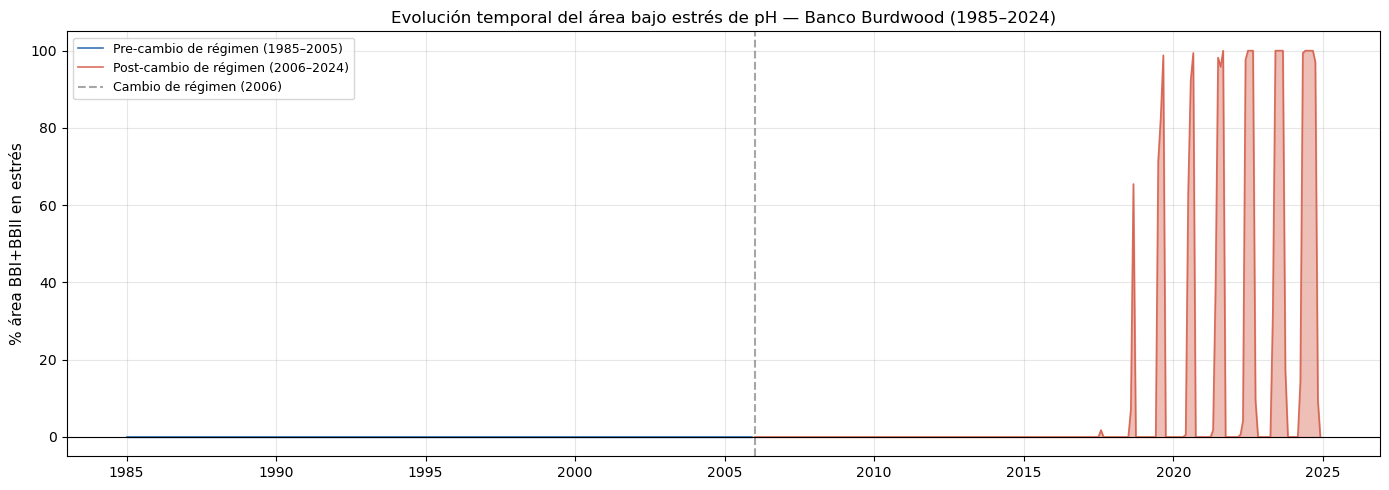

✅ stress_area_timeseries.png


In [8]:
# =============================================================================
# CELDA 6 — Gráfico de evolución temporal del área en estrés
# =============================================================================
 
fig, ax = plt.subplots(figsize=(14, 5))
 
# Colorear por período
for y1, y2, color, label in [
    (1985, 2005, "#2166ac", "Pre-cambio de régimen (1985–2005)"),
    (2006, 2024, "#d6604d", "Post-cambio de régimen (2006–2024)"),
]:
    mask = (df_stress_ts["year"] >= y1) & (df_stress_ts["year"] <= y2)
    ax.fill_between(df_stress_ts.loc[mask, "time"],
                    df_stress_ts.loc[mask, "pct_stress"],
                    alpha=0.4, color=color)
    ax.plot(df_stress_ts.loc[mask, "time"],
            df_stress_ts.loc[mask, "pct_stress"],
            color=color, lw=1.2, alpha=0.9, label=label)
 
ax.axvline(pd.Timestamp("2006-01-01"), color="gray",
           lw=1.5, linestyle="--", alpha=0.7, label="Cambio de régimen (2006)")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("% área BBI+BBII en estrés", fontsize=11)
ax.set_title("Evolución temporal del área bajo estrés de pH — Banco Burdwood (1985–2024)",
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stress_area_timeseries.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ stress_area_timeseries.png")

#### Mapas de % de meses en estrés por período (P1 y P2)

C:\Users\gisel\AppData\Local\Temp\ipykernel_18168\1352258891.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


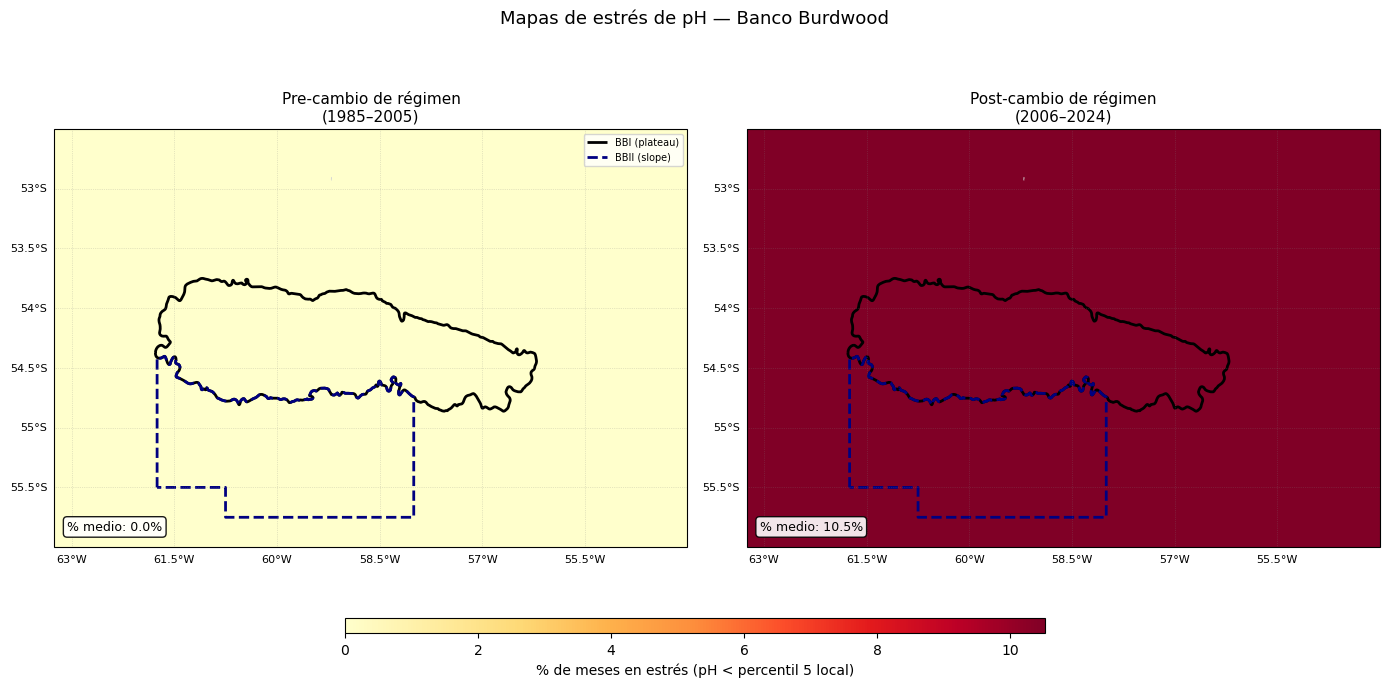

✅ stress_maps_pre_post.png


In [11]:
# =============================================================================
# CELDA 7 — Mapas de % de meses en estrés por período (P1 y P2)
# =============================================================================
 
def stress_pct_map(stress_mask, year_start, year_end):
    """% de meses en estrés por píxel para un período dado."""
    mask_period = stress_mask.sel(
        time=stress_mask.time.dt.year.isin(range(year_start, year_end + 1))
    )
    return 100 * mask_period.sum(dim="time") / mask_period.sizes["time"]
 
 
# Calcular sobre bbox completo (para los mapas)
stress_mask_bbox = ph < ph_p05
pct_pre  = stress_pct_map(stress_mask_bbox, *PERIOD_PRE)
pct_post = stress_pct_map(stress_mask_bbox, *PERIOD_POST)
 
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw={"projection": proj})
 
# Escala compartida
all_vals = np.concatenate([pct_pre.values.ravel(), pct_post.values.ravel()])
vmax     = np.nanpercentile(all_vals, 98)
 
for ax, pct_map, title, color_line in [
    (axes[0], pct_pre,  f"Pre-cambio de régimen\n(1985–2005)", "#2166ac"),
    (axes[1], pct_post, f"Post-cambio de régimen\n(2006–2024)", "#d6604d"),
]:
    im = pct_map.plot(
        ax=ax, transform=proj,
        cmap="YlOrRd", vmin=0, vmax=vmax,
        add_colorbar=False, add_labels=False,
    )
 
    bbi_shape.boundary.plot(ax=ax, transform=proj,
                             color="black", linewidth=2, label="BBI (plateau)")
    bbii_shape.boundary.plot(ax=ax, transform=proj,
                              color="navy", linewidth=2,
                              linestyle="--", label="BBII (slope)")
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
 
    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                       color="gray", alpha=0.4, linestyle=":")
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
 
    ax.text(0.02, 0.04, f"% medio: {float(pct_map.mean()):.1f}%",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
    ax.set_title(title, fontsize=11, pad=6)
 
axes[0].legend(loc="upper right", fontsize=7)
 
cbar_ax = fig.add_axes([0.25, -0.02, 0.5, 0.025])
sm = plt.cm.ScalarMappable(cmap="YlOrRd",
                            norm=mcolors.Normalize(vmin=0, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
             label="% de meses en estrés (pH < percentil 5 local)")
 
plt.suptitle("Mapas de estrés de pH — Banco Burdwood", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stress_maps_pre_post.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ stress_maps_pre_post.png")

#### Mapas de pH invernal pre/post y diferencia

C:\Users\gisel\AppData\Local\Temp\ipykernel_18168\1529867642.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


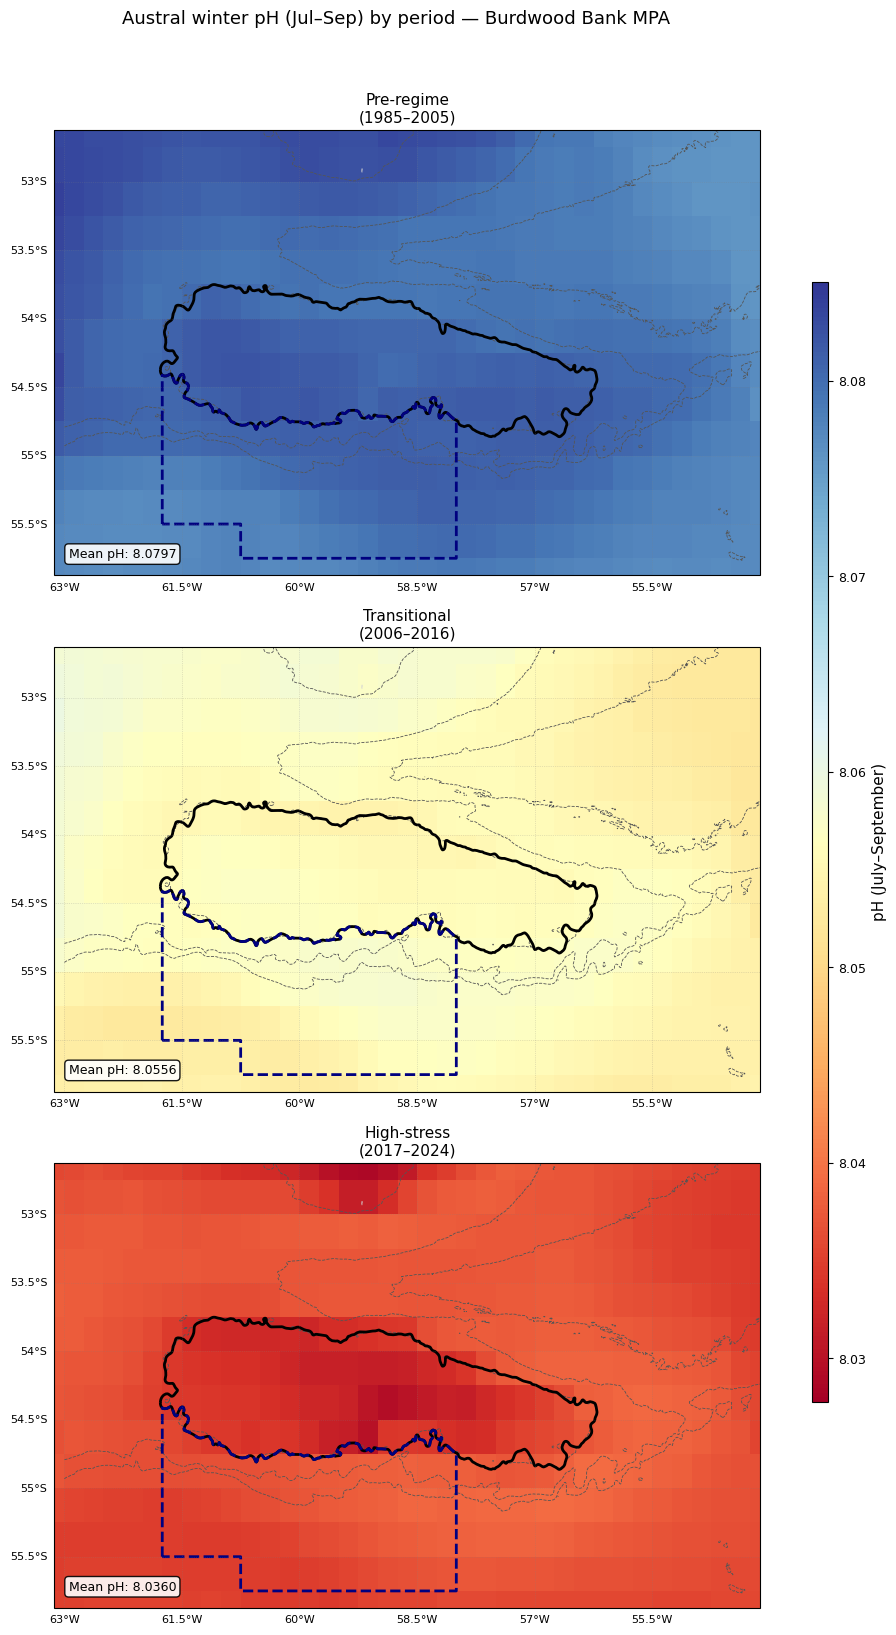

✅ winter_ph_regime_maps.png


In [18]:
# =============================================================================
# CELDA 8 — Mapas de pH invernal pre/post y diferencia
# =============================================================================
 
def winter_mean(da, year_start, year_end, months=WINTER_MONTHS):
    """pH medio del trimestre invernal para un período dado."""
    period = da.sel(time=da.time.dt.year.isin(range(year_start, year_end + 1)))
    winter = period.sel(time=period.time.dt.month.isin(months))
    return winter.mean(dim="time")
 


PERIODOS_MAPAS = [
    (1985, 2005, "Pre-regime\n(1985–2005)"),
    (2006, 2016, "Transitional\n(2006–2016)"),
    (2017, 2024, "High-stress\n(2017–2024)"),
]

ph_maps = [(winter_mean(ph, y1, y2), title) 
           for y1, y2, title in PERIODOS_MAPAS]

vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001


fig, axes = plt.subplots(3, 1, figsize=(8, 16),
                          subplot_kw={"projection": proj})

plt.rcParams.update({
    "font.size"       : 11,
    "axes.titlesize"  : 12,
    "axes.labelsize"  : 11,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
})

# --- Paneles 1 y 2: misma escala ---
for ax, (data, title) in zip(axes, ph_maps):
    
    im_abs = data.plot(
        ax=ax, transform=proj,
        cmap="RdYlBu", vmin=vmin_abs, vmax=vmax_abs,
        add_colorbar=False, add_labels=False,
    )
    bath = xr.open_dataset(os.path.join(SHAPES_DIR, "gebco_2025_n-52.0_s-56.0_w-63.0_e-54.0.nc"))["elevation"]
    bath.plot.contour(
    ax=ax, transform=proj,
    levels=[-200, -1000, -2000],
    colors=["#555555"], linewidths=[0.6],
    add_labels=False
    )
    
    bbi_shape.boundary.plot(ax=ax, transform=proj, color="black", linewidth=2)
    bbii_shape.boundary.plot(ax=ax, transform=proj, color="navy", linewidth=2, linestyle="--")
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.4, linestyle=":")
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
    ax.text(0.02, 0.04, f"Mean pH: {float(data.mean()):.4f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_extent([-63.125, -54.125, -55.875, -52.625], crs=proj)
# Colorbar compartida para paneles 1 y 2
cbar_ax1 = fig.add_axes([1.02, 0.15, 0.02, 0.7])
sm1 = plt.cm.ScalarMappable(cmap="RdYlBu",
                              norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
sm1.set_array([])
fig.colorbar(sm1, cax=cbar_ax1, orientation="vertical", label="pH (July–September)")

 
plt.suptitle(
    "Austral winter pH (Jul–Sep) by period — Burdwood Bank MPA",
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "winter_ph_regime_maps.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ winter_ph_regime_maps.png")

In [15]:
print(f"lon: {float(ph.longitude.min()):.3f} → {float(ph.longitude.max()):.3f}")
print(f"lat: {float(ph.latitude.min()):.3f} → {float(ph.latitude.max()):.3f}")

lon: -63.125 → -54.125
lat: -55.875 → -52.625


#### Resumen cuantitativo para el paper

In [34]:
# =============================================================================
# CELDA 9 — Resumen cuantitativo para el paper
# =============================================================================
print(f"\n  pH INVERNAL (jul–sep) POR PERÍODO:")
for (y1, y2, label), (ph_map, _) in zip(PERIODOS_MAPAS, ph_maps):
    print(f"    {label.replace(chr(10), ' ')}: {float(ph_map.mean()):.4f}")

ph_pre  = ph_maps[0][0]
ph_tran = ph_maps[1][0]
ph_est  = ph_maps[2][0]
print(f"\n    Δ pre→transición : {float(ph_tran.mean()) - float(ph_pre.mean()):.4f}")
print(f"    Δ pre→estrés     : {float(ph_est.mean())  - float(ph_pre.mean()):.4f}")
print(f"    Δ transición→estrés: {float(ph_est.mean()) - float(ph_tran.mean()):.4f}")


  pH INVERNAL (jul–sep) POR PERÍODO:
    Pre-régimen (1985–2005): 8.0797
    Transición (2006–2016): 8.0556
    Estrés intenso (2017–2024): 8.0360

    Δ pre→transición : -0.0240
    Δ pre→estrés     : -0.0437
    Δ transición→estrés: -0.0196


#### mapas con aragonita y spco2

C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


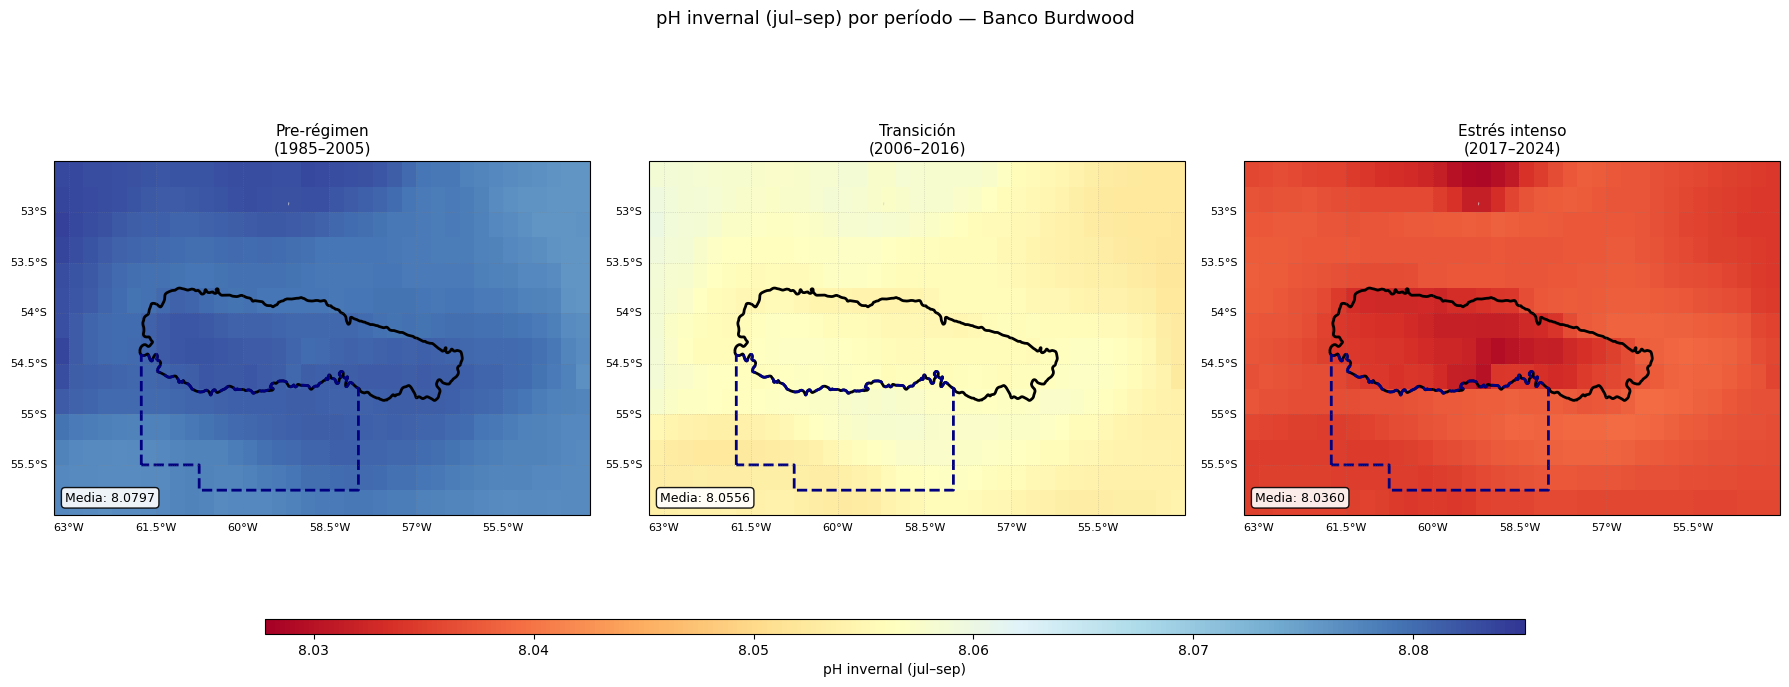

✅ winter_ph_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


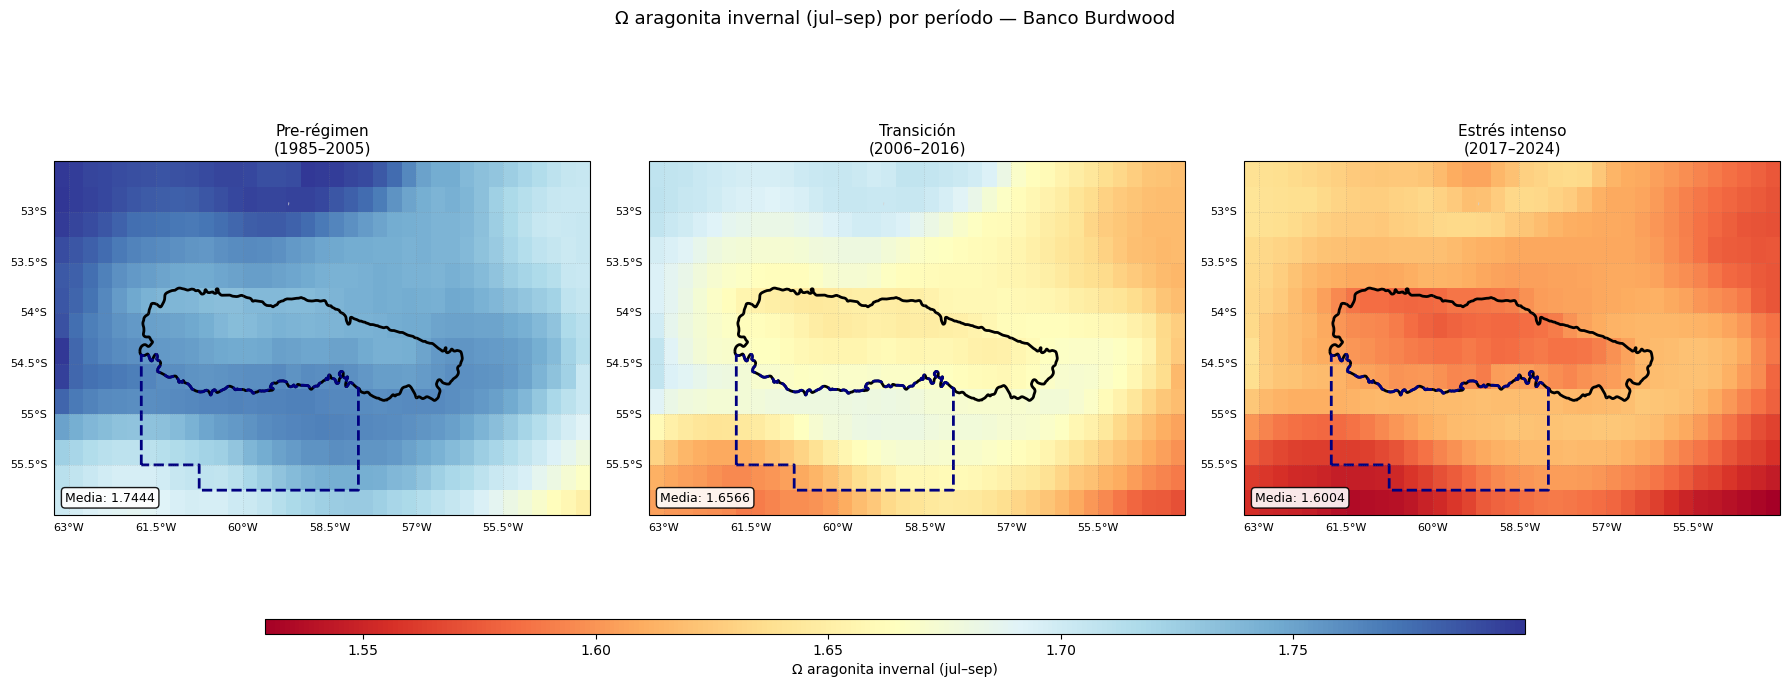

✅ winter_omega_ar_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


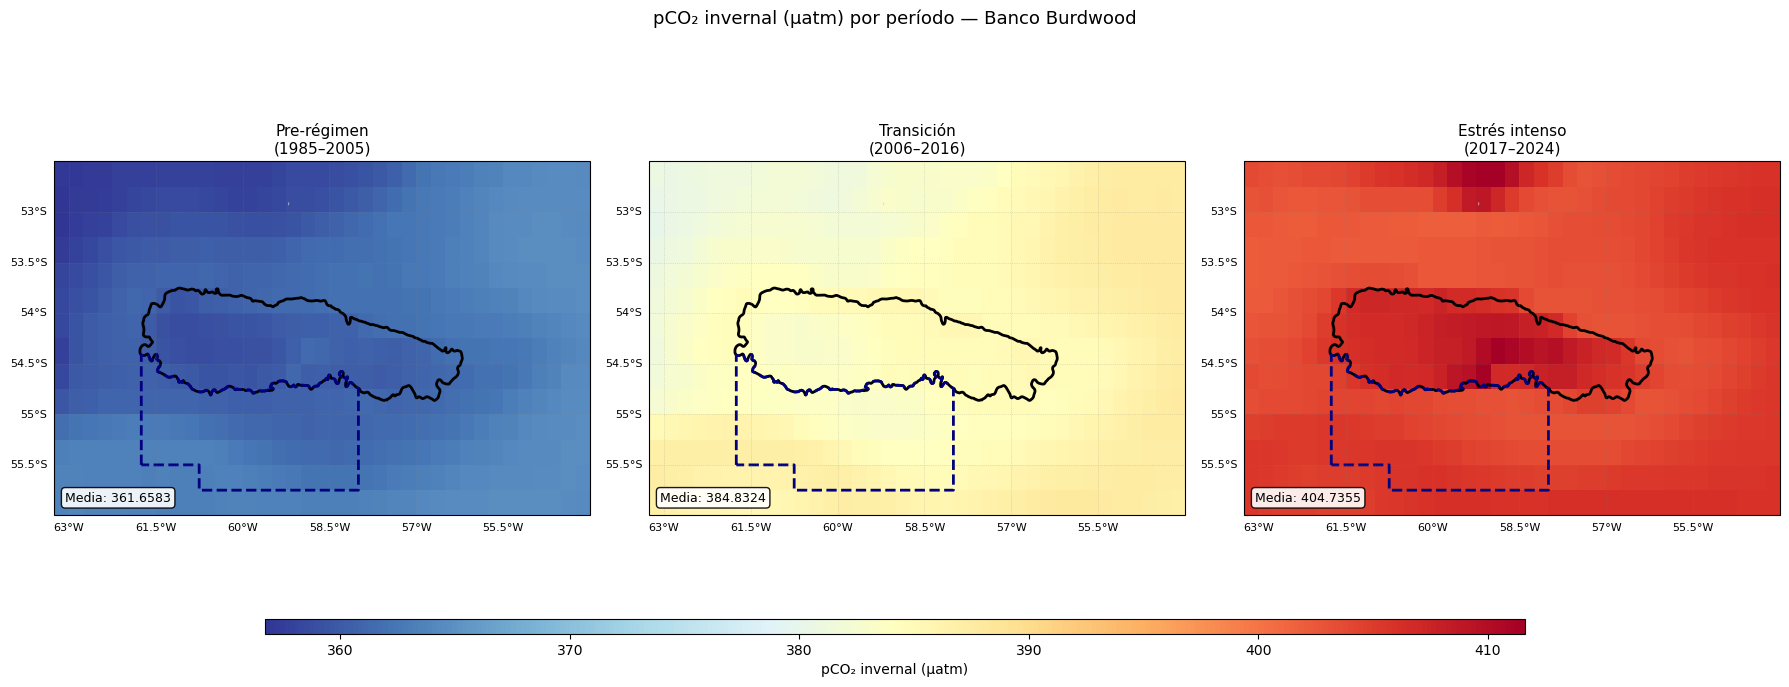

✅ winter_spco2_maps.png


In [40]:
VARIABLES_MAPAS = [
    ("ph",       "pH invernal (jul–sep)",         "RdYlBu"),
    ("omega_ar", "Ω aragonita invernal (jul–sep)", "RdYlBu"),
    ("spco2",    "pCO₂ invernal (µatm)",           "RdYlBu_r"),
]

for varname, var_label, cmap in VARIABLES_MAPAS:
    da = ds[varname]
    ph_maps = [(winter_mean(da, y1, y2), title)
               for y1, y2, title in PERIODOS_MAPAS]

    vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
    vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001

    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw={"projection": proj})

    for ax, (data, title) in zip(axes, ph_maps):
        im = data.plot(
            ax=ax, transform=proj,
            cmap=cmap, vmin=vmin_abs, vmax=vmax_abs,
            add_colorbar=False, add_labels=False,
        )
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color="black", linewidth=2)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color="navy", linewidth=2, linestyle="--")
        ax.coastlines(resolution="10m", color="black", linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
        ax.text(0.02, 0.04, f"Media: {float(data.mean()):.4f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
        ax.set_title(title, fontsize=11, pad=6)

    cbar_ax = fig.add_axes([0.15, -0.02, 0.7, 0.025])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", label=var_label)

    plt.suptitle(f"{var_label} por período — Banco Burdwood", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"winter_{varname}_maps.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ winter_{varname}_maps.png")

#### mapas con puntos de cambio de regimen adaptado por variable

In [42]:
PERIODOS_POR_VAR = {
    "ph"      : [(1985, 2005, "Pre-régimen\n(1985–2005)"),
                 (2006, 2016, "Transición\n(2006–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
    "omega_ar": [(1985, 2006, "Pre-régimen\n(1985–2006)"),
                 (2007, 2016, "Transición\n(2007–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
    "spco2"   : [(1985, 2005, "Pre-régimen\n(1985–2005)"),
                 (2006, 2016, "Transición\n(2006–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
}

C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


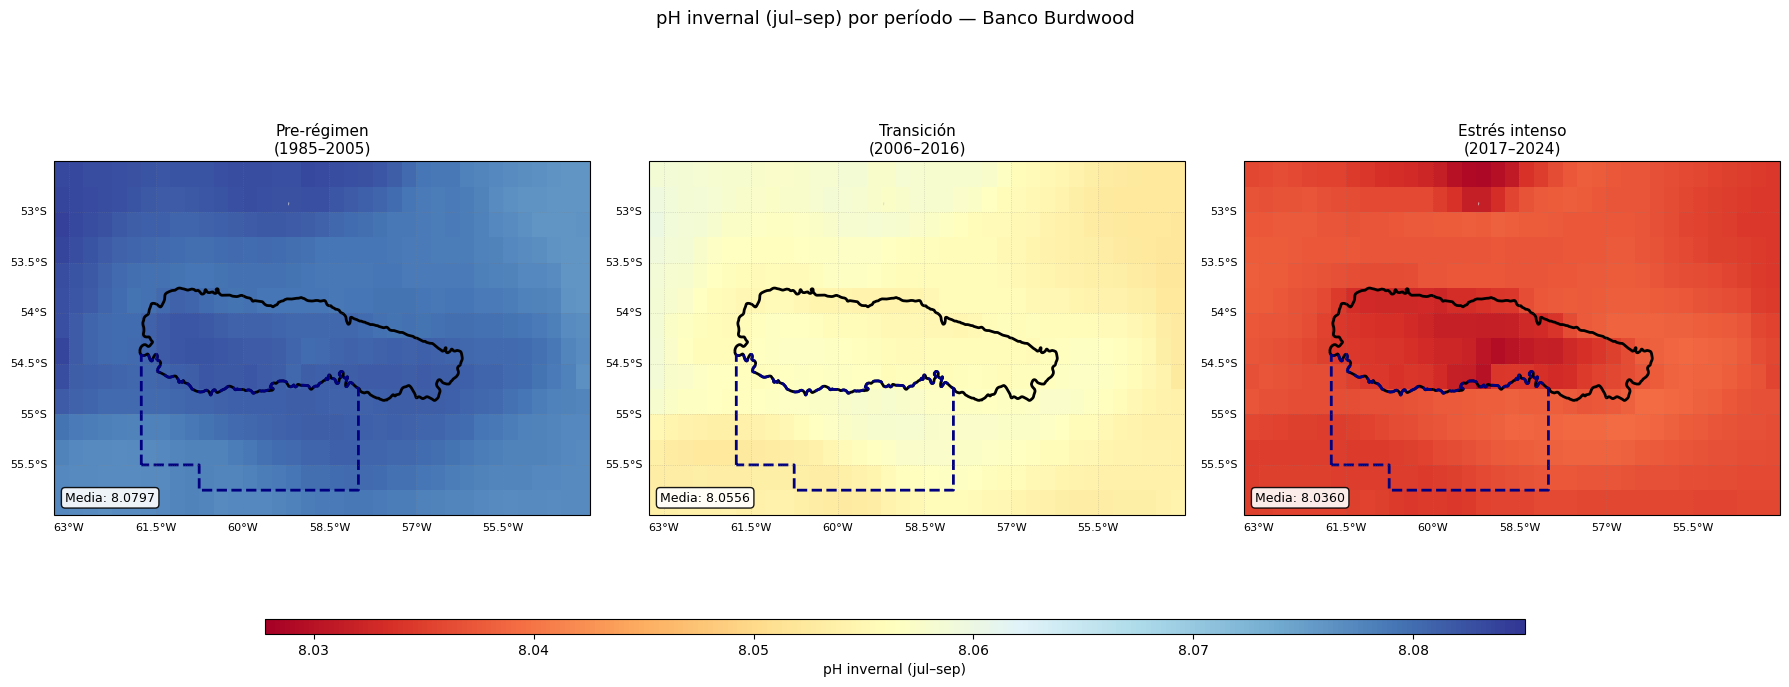

✅ winter_ph_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


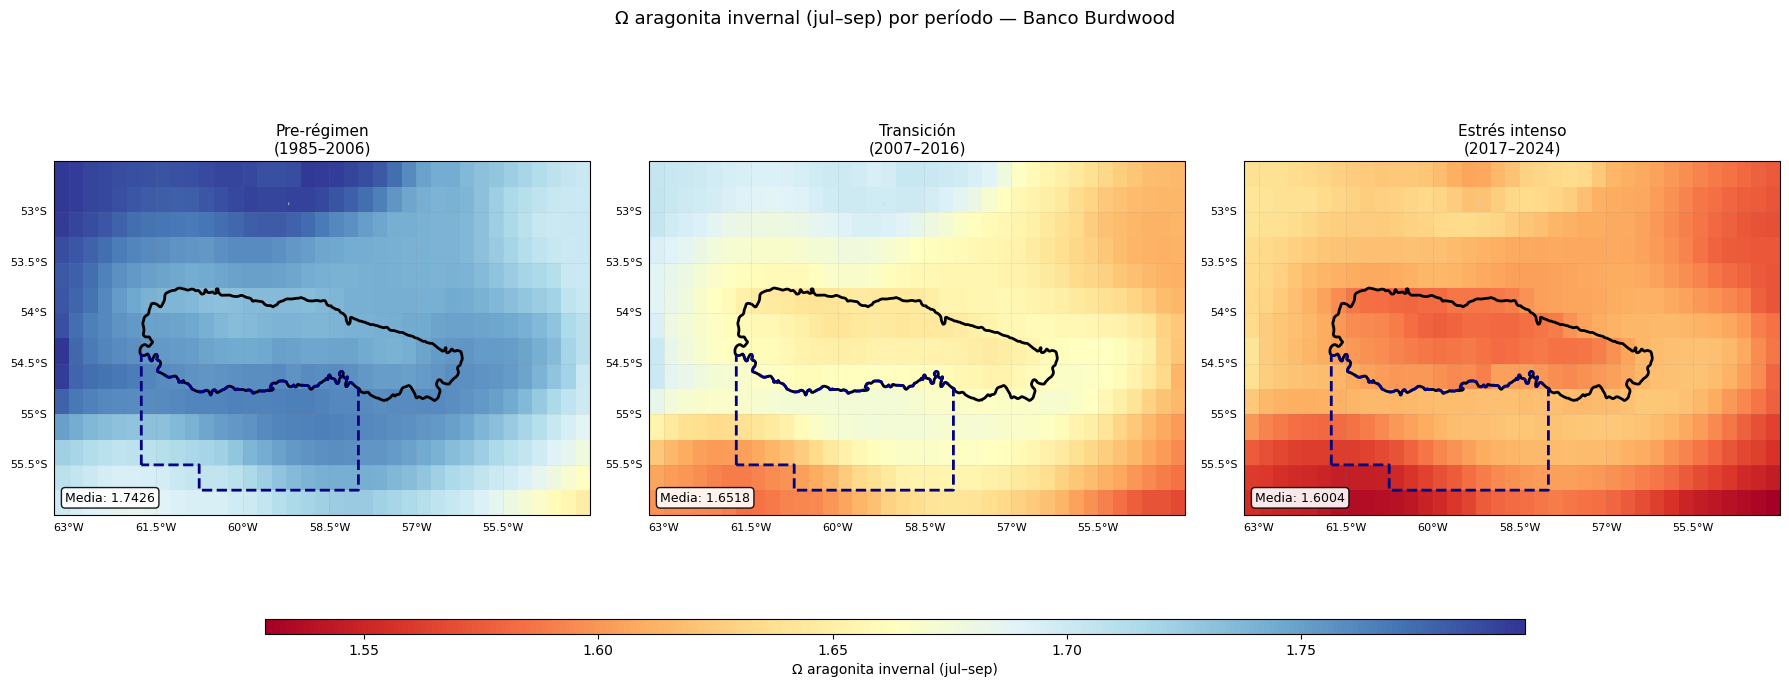

✅ winter_omega_ar_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


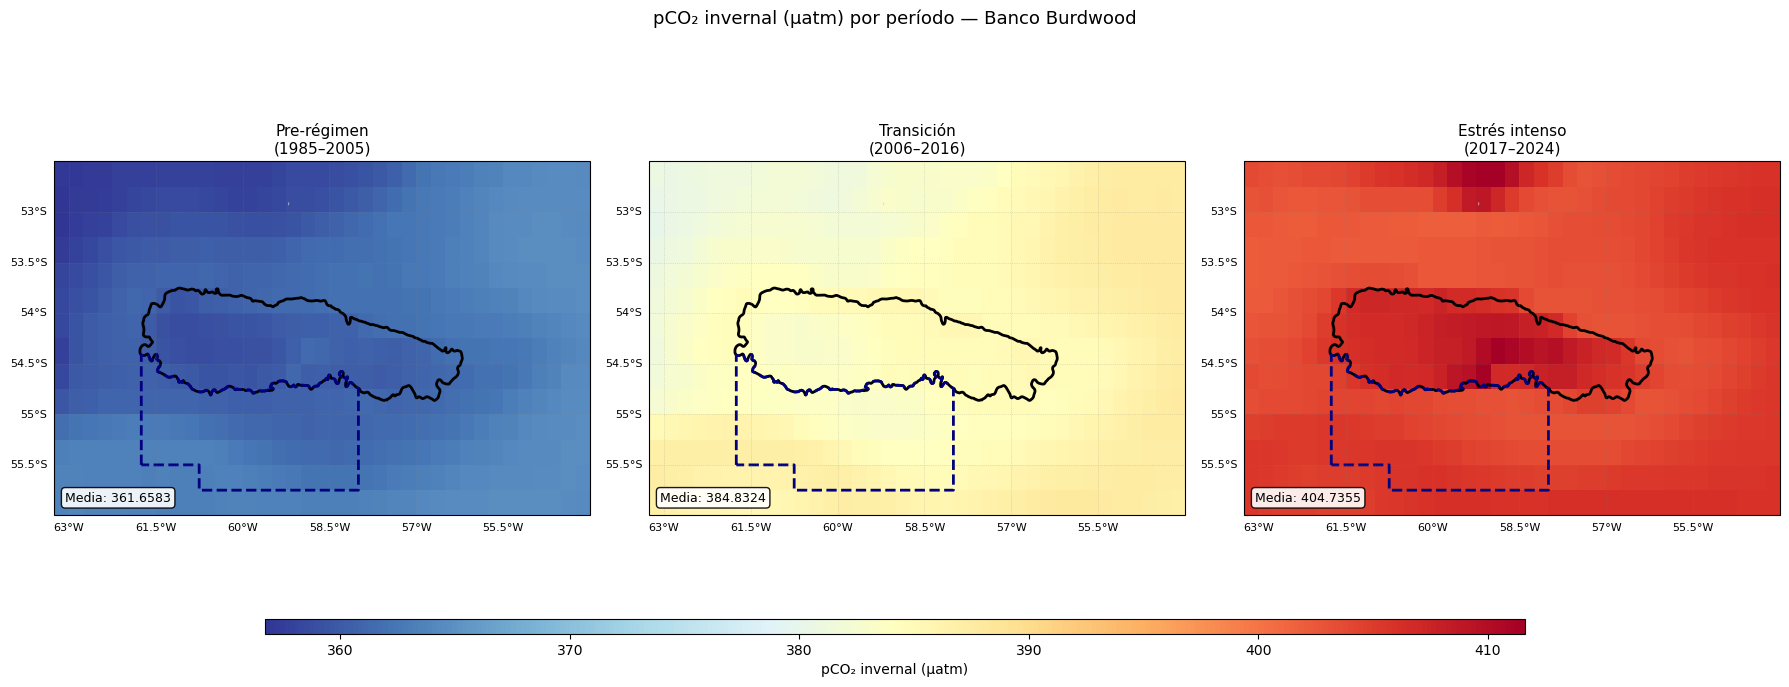

✅ winter_spco2_maps.png


In [43]:
VARIABLES_MAPAS = [
    ("ph",       "pH invernal (jul–sep)",         "RdYlBu"),
    ("omega_ar", "Ω aragonita invernal (jul–sep)", "RdYlBu"),
    ("spco2",    "pCO₂ invernal (µatm)",           "RdYlBu_r"),
]

for varname, var_label, cmap in VARIABLES_MAPAS:
    da = ds[varname]
    periodos = PERIODOS_POR_VAR[varname]
    ph_maps  = [(winter_mean(da, y1, y2), title) for y1, y2, title in periodos]

    vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
    vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001

    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw={"projection": proj})

    for ax, (data, title) in zip(axes, ph_maps):
        im = data.plot(
            ax=ax, transform=proj,
            cmap=cmap, vmin=vmin_abs, vmax=vmax_abs,
            add_colorbar=False, add_labels=False,
        )
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color="black", linewidth=2)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color="navy", linewidth=2, linestyle="--")
        ax.coastlines(resolution="10m", color="black", linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
        ax.text(0.02, 0.04, f"Media: {float(data.mean()):.4f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
        ax.set_title(title, fontsize=11, pad=6)

    cbar_ax = fig.add_axes([0.15, -0.02, 0.7, 0.025])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", label=var_label)

    plt.suptitle(f"{var_label} por período — Banco Burdwood", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"winter_{varname}_maps.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ winter_{varname}_maps.png")

### Fig 4 para el paper

C:\Users\gisel\AppData\Local\Temp\ipykernel_18168\759806601.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


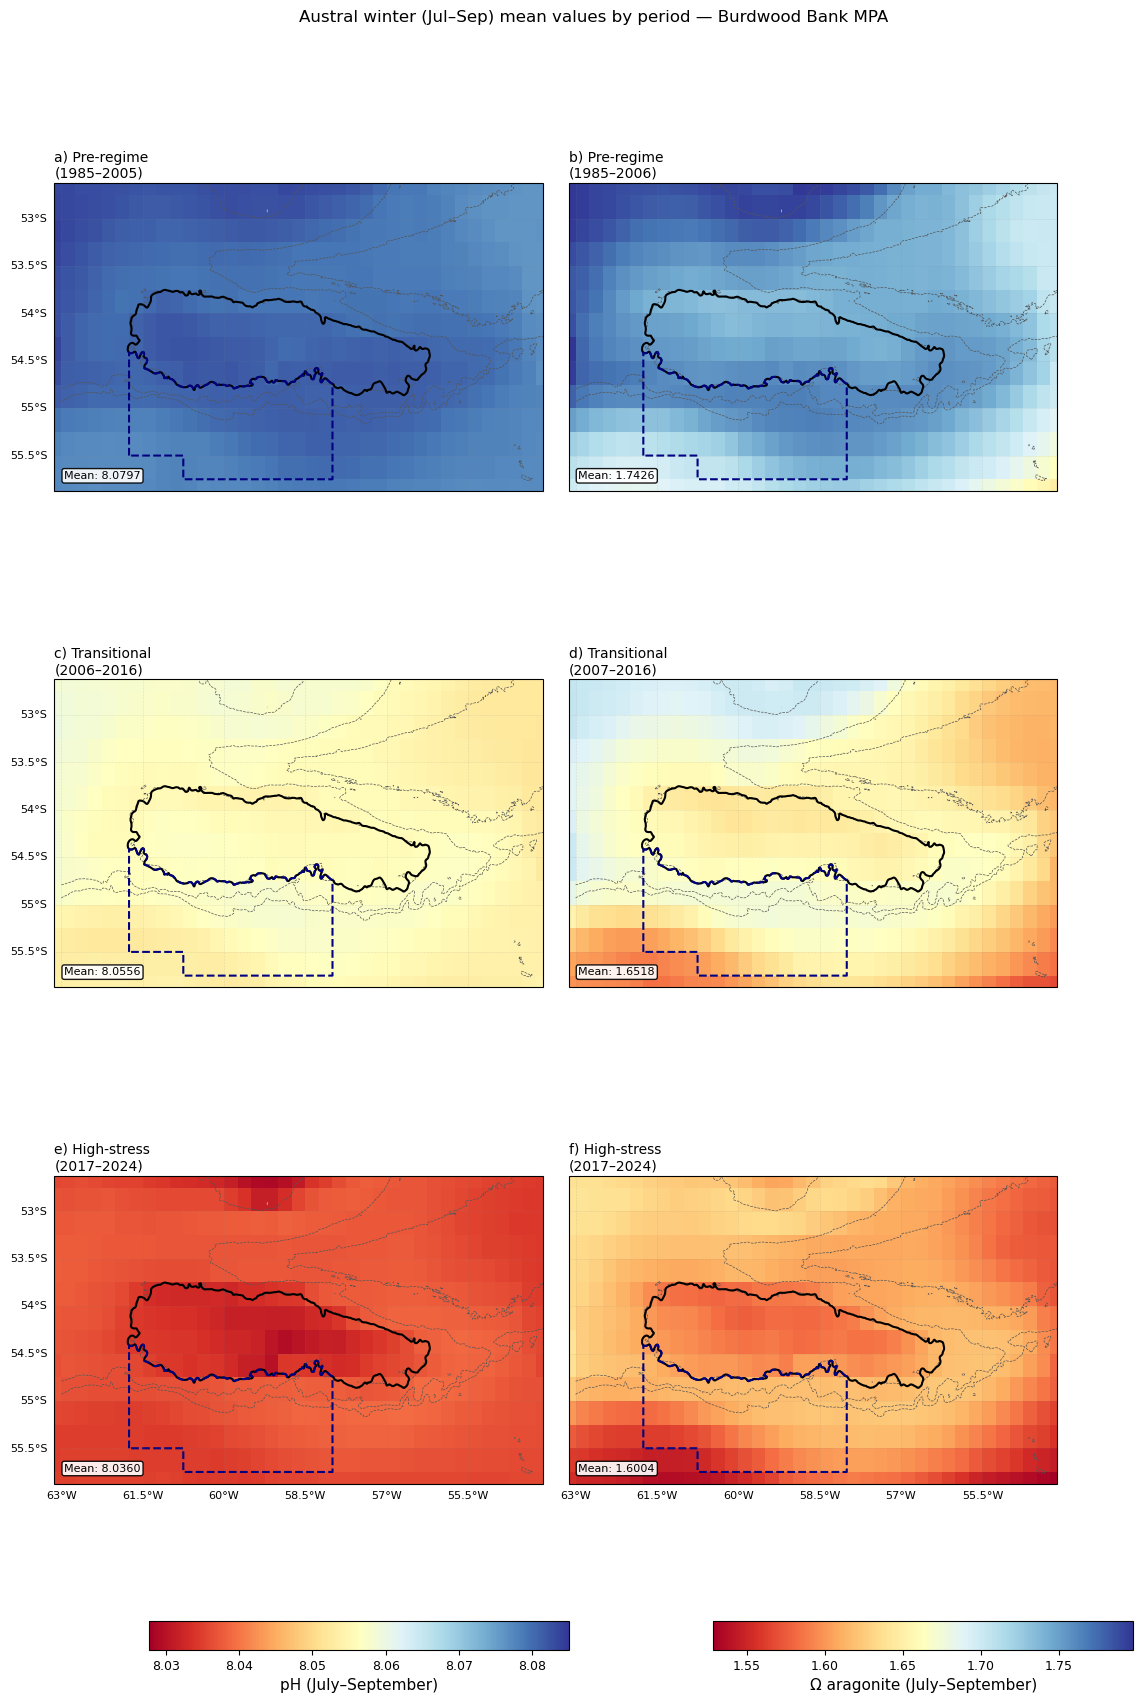

✅ Fig4_winter_maps.png guardada


In [22]:
WINTER_MONTHS = [7, 8, 9]
 
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

# =============================================================================
# Cargar datos y shapes
# =============================================================================
 
ds         = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
bath       = xr.open_dataset(os.path.join(SHAPES_DIR,
             "gebco_2025_n-52.0_s-56.0_w-63.0_e-54.0.nc"))["elevation"]
 
 
def winter_mean(da, y1, y2):
    period = da.sel(time=da.time.dt.year.isin(range(y1, y2 + 1)))
    winter = period.sel(time=period.time.dt.month.isin(WINTER_MONTHS))
    return winter.mean(dim="time")
 
 
# Períodos por variable (cambio de régimen distinto)
COLS = [
    {
        "varname"  : "ph",
        "cmap"     : "RdYlBu",
        "cbar_label": "pH (July–September)",
        "mean_fmt" : ".4f",
        "periods"  : [
            (1985, 2005, "a) Pre-regime\n(1985–2005)"),
            (2006, 2016, "c) Transitional\n(2006–2016)"),
            (2017, 2024, "e) High-stress\n(2017–2024)"),
        ],
    },
    {
        "varname"  : "omega_ar",
        "cmap"     : "RdYlBu",
        "cbar_label": "Ω aragonite (July–September)",
        "mean_fmt" : ".4f",
        "periods"  : [
            (1985, 2006, "b) Pre-regime\n(1985–2006)"),
            (2007, 2016, "d) Transitional\n(2007–2016)"),
            (2017, 2024, "f) High-stress\n(2017–2024)"),
        ],
    },
]
 
# =============================================================================
# Calcular mapas y escalas
# =============================================================================
 
for col in COLS:
    da = ds[col["varname"]]
    col["maps"] = [(winter_mean(da, y1, y2), title)
                   for y1, y2, title in col["periods"]]
    col["vmin"] = min(float(m.min()) for m, _ in col["maps"]) - 0.001
    col["vmax"] = max(float(m.max()) for m, _ in col["maps"]) + 0.001
 
# =============================================================================
# Figura: 3 filas × 2 columnas
# =============================================================================
 
proj = ccrs.PlateCarree()
EXTENT = [-63.125, -54.125, -55.875, -52.625]
 
fig, axes = plt.subplots(3, 2, figsize=(12, 16),
                          subplot_kw={"projection": proj})
 
for c, col in enumerate(COLS):
    for r, (data, title) in enumerate(col["maps"]):
        ax = axes[r, c]
 
        # Mapa
        ax.pcolormesh(
            data.longitude, data.latitude, data.values,
            transform=proj,
            cmap=col["cmap"],
            vmin=col["vmin"], vmax=col["vmax"],
        )
 
        # Batimetría
        lons = bath.lon.values if "lon" in bath.coords else bath.longitude.values
        lats = bath.lat.values if "lat" in bath.coords else bath.latitude.values
        ax.contour(lons, lats, bath.values,
                   levels=[-2000, -1000, -200],
                   colors=["#555555"], linewidths=[0.5],
                   transform=proj)
 
        # Shapes
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color="black", linewidth=1.5)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color="navy", linewidth=1.5, linestyle="--")
 
        # Coastline y land
        ax.coastlines(resolution="10m", color="black", linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
 
        # Grilla
        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels   = False
        gl.right_labels = False
        gl.left_labels  = (c == 0)   # etiquetas Y solo en columna izquierda
        gl.bottom_labels = (r == 2)  # etiquetas X solo en fila inferior
        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}
 
        # Anotación media
        fmt = col["mean_fmt"]
        ax.text(0.02, 0.04,
                f"Mean: {float(data.mean()):{fmt}}",
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.9),
                zorder=5)
 
        ax.set_title(title, fontsize=10, loc="left", pad=4)
        ax.set_extent(EXTENT, crs=proj)
 
    # Colorbar por columna
    cbar_ax = fig.add_axes([
        0.13 + c * 0.47,  # x
        -0.02,             # y — debajo de la figura
        0.35,              # width
        0.018              # height
    ])
    sm = plt.cm.ScalarMappable(
        cmap=col["cmap"],
        norm=mcolors.Normalize(vmin=col["vmin"], vmax=col["vmax"])
    )
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
                 label=col["cbar_label"])
 
plt.suptitle(
    "Austral winter (Jul–Sep) mean values by period — Burdwood Bank MPA",
    fontsize=12, y=1.005
)
 
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.savefig(os.path.join(FIGURES_DIR, "Fig4_winter_maps.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig4_winter_maps.png guardada")
 

In [26]:
omega_ar_bbox = ds["omega_ar"].where(inside)
omega_ar_p05  = omega_ar_bbox.quantile(0.05, dim="time")

print(f"Ω_ar percentil 5 — rango espacial:")
print(f"  min : {float(omega_ar_p05.min()):.4f}")
print(f"  max : {float(omega_ar_p05.max()):.4f}")
print(f"  mean: {float(omega_ar_p05.mean()):.4f}")
print(f"\nComparación con umbral biológico (1.5):")
print(f"  % píxeles con p5 < 1.5: {float((omega_ar_p05 < 1.5).mean()*100):.1f}%")

Ω_ar percentil 5 — rango espacial:
  min : 1.5448
  max : 1.6402
  mean: 1.6094

Comparación con umbral biológico (1.5):
  % píxeles con p5 < 1.5: 0.0%


C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [28]:
# Mínimo absoluto
print(f"Min absoluto: {float(omega_ar_bbox.min()):.4f}")
print(f"Max absoluto: {float(omega_ar_bbox.max()):.4f}")

# Mínimo anual — primero promediar espacialmente, luego mínimo mensual por año
omega_ar_spatial_min = omega_ar_bbox.min(dim=["latitude", "longitude"])
df_min = omega_ar_spatial_min.to_dataframe(name="min_omega_ar").reset_index()
df_min["year"] = pd.to_datetime(df_min["time"]).dt.year

annual_min = df_min.groupby("year")["min_omega_ar"].min()
print("\nMínimo anual (últimos 10 años):")
print(annual_min.tail(10).to_string())

Min absoluto: 1.4501
Max absoluto: 2.3221

Mínimo anual (últimos 10 años):
year
2015    1.518281
2016    1.482607
2017    1.497986
2018    1.544811
2019    1.450111
2020    1.533723
2021    1.536216
2022    1.528469
2023    1.507498
2024    1.499275


In [30]:
# ¿Cuántos meses por píxel tienen Ω_ar < 1.5?
n_below = (omega_ar_bbox < 1.5).sum(dim="time")
pct_months_below = 100 * n_below / omega_ar_bbox.sizes["time"]

print(f"% meses con Ω_ar < 1.5 por píxel:")
print(f"  max en cualquier píxel: {float(pct_months_below.max()):.2f}%")
print(f"  mean en todos los píxeles: {float(pct_months_below.mean()):.2f}%")
print(f"  (el percentil 5 requiere >5% → ningún píxel llega)")

% meses con Ω_ar < 1.5 por píxel:
  max en cualquier píxel: 0.62%
  mean en todos los píxeles: 0.02%
  (el percentil 5 requiere >5% → ningún píxel llega)


### Fig 5

C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Primer evento pH    : 2017-08
Primer evento Ω_ar  : 2016-06


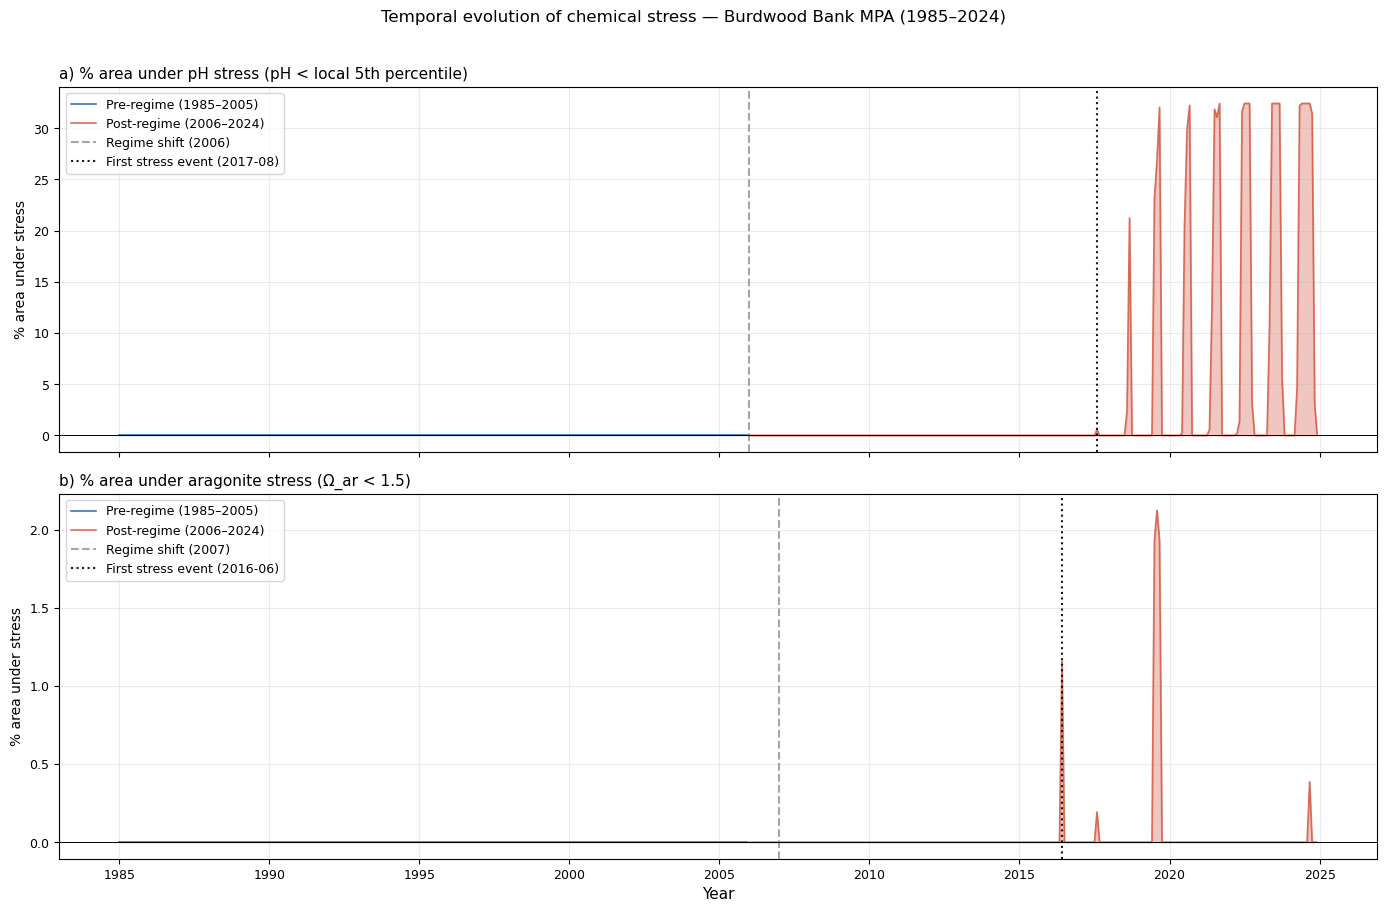

✅ Fig5_stress_timeseries.png guardada


In [31]:
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})
 
# =============================================================================
# Cargar datos y máscara BBI+BBII
# =============================================================================
 
ds         = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
ph         = ds["ph"]
omega_ar   = ds["omega_ar"]
 
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
 
# Máscara BBI+BBII
bb_total = unary_union([bbi_shape.geometry.union_all(),
                         bbii_shape.geometry.union_all()])
lats = ph.latitude.values
lons = ph.longitude.values
LON, LAT = np.meshgrid(lons, lats)
res    = 0.25
pixels = [box(lo-res/2, la-res/2, lo+res/2, la+res/2)
          for lo, la in zip(LON.ravel(), LAT.ravel())]
inside = np.array([bb_total.intersects(p) for p in pixels]).reshape(LAT.shape)
 
ph_bb       = ph.where(inside)
omega_ar_bb = omega_ar.where(inside)
 
 
# =============================================================================
# Calcular series temporales de % área en estrés
# =============================================================================
 
# pH: percentil 5 local por píxel
ph_p05 = ph_bb.quantile(0.05, dim="time")
stress_ph = ph_bb < ph_p05
 
# Ω_ar: umbral biológico absoluto
THRESH_AR = 1.5
stress_ar = omega_ar_bb < THRESH_AR
 
def pct_stress_ts(stress_mask):
    n_stress = stress_mask.sum(dim=["latitude", "longitude"])
    n_valid  = (~stress_mask.isnull()).sum(dim=["latitude", "longitude"])
    pct = 100 * n_stress / n_valid
    df  = pct.to_dataframe(name="pct_stress").reset_index()
    df["time"]  = pd.to_datetime(df["time"])
    df["year"]  = df["time"].dt.year
    return df
 
df_ph = pct_stress_ts(stress_ph)
df_ar = pct_stress_ts(stress_ar)
 
# Primer evento de estrés
t_first_ph = df_ph[df_ph["pct_stress"] > 0]["time"].min()
t_first_ar = df_ar[df_ar["pct_stress"] > 0]["time"].min()
 
print(f"Primer evento pH    : {t_first_ph.strftime('%Y-%m')}")
print(f"Primer evento Ω_ar  : {t_first_ar.strftime('%Y-%m')}")
 
 
# =============================================================================
# Figura 5: dos paneles
# =============================================================================
 
PERIODS = [
    (1985, 2005, "#2166ac", "Pre-regime (1985–2005)"),
    (2006, 2024, "#d6604d", "Post-regime (2006–2024)"),
]
 
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
 
panels = [
    (axes[0], df_ph, t_first_ph, "2006-01-01",
     "a) % area under pH stress (pH < local 5th percentile)",
     "% area under stress"),
    (axes[1], df_ar, t_first_ar, "2007-01-01",
     f"b) % area under aragonite stress (Ω_ar < {THRESH_AR})",
     "% area under stress"),
]
 
for ax, df, t_first, t_regime, title, ylabel in panels:
    for y1, y2, color, label in PERIODS:
        mask = (df["year"] >= y1) & (df["year"] <= y2)
        ax.fill_between(df.loc[mask, "time"],
                        df.loc[mask, "pct_stress"],
                        alpha=0.35, color=color)
        ax.plot(df.loc[mask, "time"],
                df.loc[mask, "pct_stress"],
                color=color, lw=1.2, alpha=0.9, label=label)
 
    # Línea de cambio de régimen
    ax.axvline(pd.Timestamp(t_regime), color="gray",
               lw=1.5, linestyle="--", alpha=0.7,
               label=f"Regime shift ({t_regime[:4]})")
 
    # Primer evento de estrés
    ax.axvline(t_first, color="black", lw=1.5,
               linestyle=":", alpha=0.9,
               label=f"First stress event ({t_first.strftime('%Y-%m')})")
 
    ax.axhline(0, color="black", lw=0.7)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, loc="left")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.25)
 
axes[1].set_xlabel("Year", fontsize=11)
 
plt.suptitle(
    "Temporal evolution of chemical stress — Burdwood Bank MPA (1985–2024)",
    fontsize=12, y=1.01
)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig5_stress_timeseries.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig5_stress_timeseries.png guardada")
 

In [32]:
# ¿Cuántos píxeles válidos tiene la máscara?
print(f"Píxeles dentro de BBI+BBII: {inside.sum()}")

# ¿Cuándo es el primer evento?
print(f"Primer evento Ω_ar < 1.5: {t_first_ar.strftime('%Y-%m')}")

# ¿Qué % del área es ese primer evento?
first_event = df_ar[df_ar["pct_stress"] > 0].iloc[0]
print(f"  % área en ese mes: {first_event['pct_stress']:.3f}%")
print(f"  Fecha: {first_event['time'].strftime('%Y-%m')}")

Píxeles dentro de BBI+BBII: 168
Primer evento Ω_ar < 1.5: 2016-06
  % área en ese mes: 1.158%
  Fecha: 2016-06
